In [1]:
!pip install -q --upgrade scikeras scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scikeras.wrappers import KerasClassifier

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print("Dataset Summary")
print("-" * 40)
print(f"Training images shape : {x_train_raw.shape}")
print(f"Training labels shape : {y_train_raw.shape}")
print(f"Testing images shape  : {x_test_raw.shape}")
print(f"Testing labels shape  : {y_test_raw.shape}")
print(f"Number of classes     : {len(np.unique(y_train_raw))}")
print(f"Pixel value range     : [{x_train_raw.min()}, {x_train_raw.max()}]")

Dataset Summary
----------------------------------------
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)
Number of classes     : 10
Pixel value range     : [0, 255]


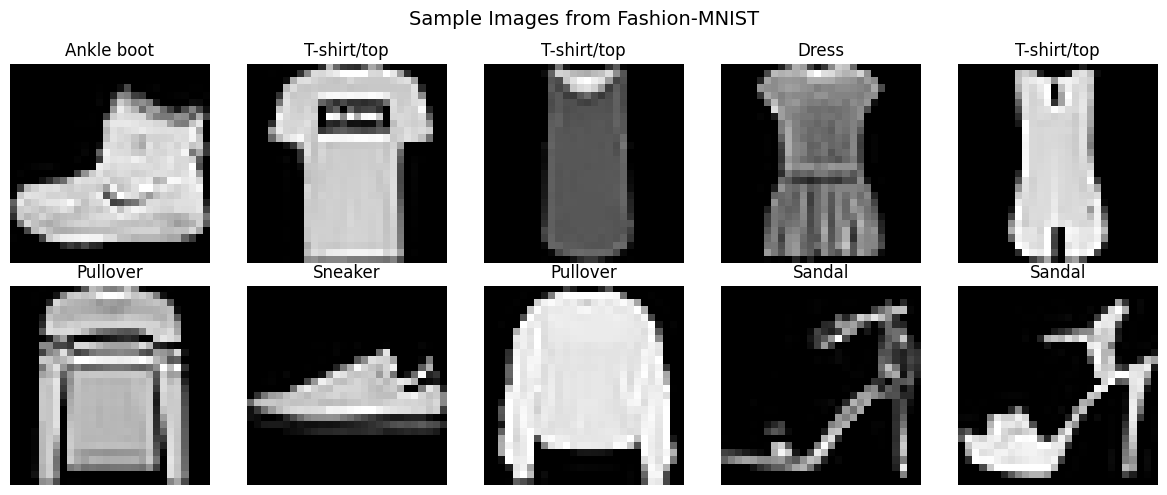

In [4]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(CLASS_NAMES[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST", fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

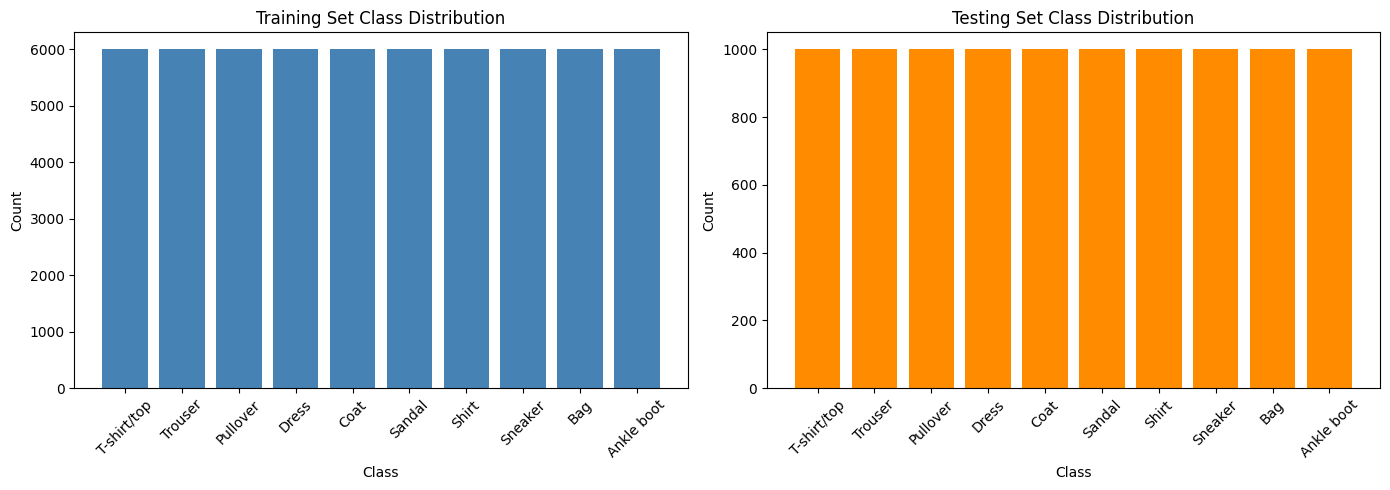

In [5]:
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts = pd.Series(y_test_raw).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(CLASS_NAMES, train_counts.values, color='steelblue')
axes[0].set_title("Training Set Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(CLASS_NAMES, test_counts.values, color='darkorange')
axes[1].set_title("Testing Set Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("Shapes BEFORE preprocessing")
print("-" * 40)
print(f"x_train: {x_train_raw.shape}, dtype={x_train_raw.dtype}")
print(f"x_test : {x_test_raw.shape}, dtype={x_test_raw.dtype}")
print(f"y_train: {y_train_raw.shape}, dtype={y_train_raw.dtype}")
print(f"y_test : {y_test_raw.shape}, dtype={y_test_raw.dtype}")

# Flatten: 28x28 -> 784
x_train_flat = x_train_raw.reshape(x_train_raw.shape[0], 28 * 28)
x_test_flat = x_test_raw.reshape(x_test_raw.shape[0], 28 * 28)

# Normalize pixel values to [0, 1]
x_train = x_train_flat.astype('float32') / 255.0
x_test = x_test_flat.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("\nShapes AFTER preprocessing")
print("-" * 40)
print(f"x_train: {x_train.shape}, dtype={x_train.dtype}, range=[{x_train.min()}, {x_train.max()}]")
print(f"x_test : {x_test.shape}, dtype={x_test.dtype}, range=[{x_test.min()}, {x_test.max()}]")
print(f"y_train: {y_train.shape}, dtype={y_train.dtype}")
print(f"y_test : {y_test.shape}, dtype={y_test.dtype}")

print("\nExample: flatten of a 2x2 block [[10,20],[30,40]] -> [10,20,30,40]")
print(np.array([[10, 20], [30, 40]]).reshape(-1))

Shapes BEFORE preprocessing
----------------------------------------
x_train: (60000, 28, 28), dtype=uint8
x_test : (10000, 28, 28), dtype=uint8
y_train: (60000,), dtype=uint8
y_test : (10000,), dtype=uint8

Shapes AFTER preprocessing
----------------------------------------
x_train: (60000, 784), dtype=float32, range=[0.0, 1.0]
x_test : (10000, 784), dtype=float32, range=[0.0, 1.0]
y_train: (60000, 10), dtype=float64
y_test : (10000, 10), dtype=float64

Example: flatten of a 2x2 block [[10,20],[30,40]] -> [10,20,30,40]
[10 20 30 40]


In [7]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
print(f"\nTraining completed in {time.time() - start_time:.1f} seconds")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8195 - loss: 0.5041 - val_accuracy: 0.8522 - val_loss: 0.3992
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8635 - loss: 0.3700 - val_accuracy: 0.8610 - val_loss: 0.3791
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8767 - loss: 0.3330 - val_accuracy: 0.8602 - val_loss: 0.3702
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8861 - loss: 0.3078 - val_accuracy: 0.8672 - val_loss: 0.3638
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8923 - loss: 0.2898 - val_accuracy: 0.8710 - val_loss: 0.3564
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8972 - loss: 0.2739 - val_accuracy: 0.8728 - val_loss: 0.3553
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9035 - loss: 0.2591 - val_accuracy: 0.8703 - val_loss: 0.3691
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9063 - loss: 0.2500 -

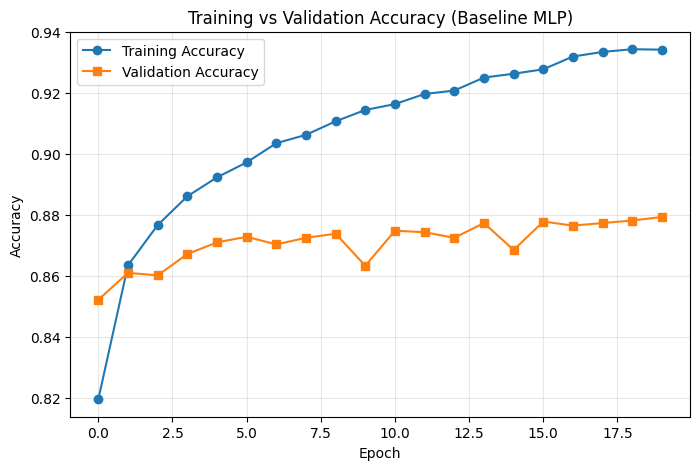

In [9]:
# Plot Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy (Baseline MLP)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('accuracy_vs_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

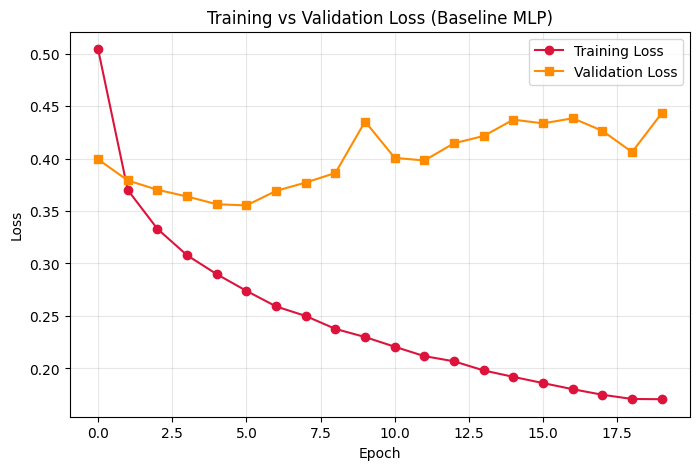

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='darkorange')
plt.title('Training vs Validation Loss (Baseline MLP)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('loss_vs_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Predictions
y_pred_probs = baseline_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Baseline Model — Test Set Metrics")
print("-" * 40)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

baseline_metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("\nClassification Report")
print("-" * 40)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Model — Test Set Metrics
----------------------------------------
Accuracy : 0.8809
Precision: 0.8836
Recall   : 0.8809
F1-score : 0.8787

Classification Report
----------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.92      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.78      0.80      1000
       Dress       0.85      0.91      0.88      1000
        Coat       0.78      0.84      0.81      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.81      0.56      0.67      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88 

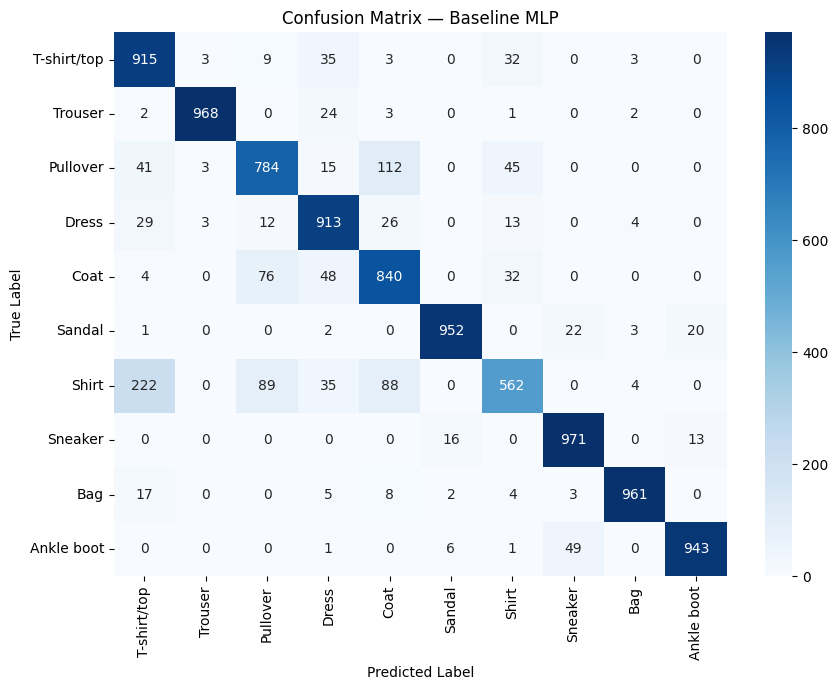

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Baseline MLP')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
def build_mlp(hidden_layers=1, hidden_neurons=128, learning_rate=0.001,
              optimizer='adam', activation='relu', dropout_rate=0.0,
              meta=None):
    """Model builder function required by SciKeras' KerasClassifier."""
    n_features_in = meta['n_features_in_'] if meta else 784
    n_classes = meta['n_classes_'] if meta else 10

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features_in,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(n_classes, activation='softmax'))

    if optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [14]:
# Wrap the builder function with SciKeras' KerasClassifier
clf = KerasClassifier(
    model=build_mlp,
    hidden_layers=1,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer='adam',
    activation='relu',
    dropout_rate=0.0,
    verbose=0,
    loss='categorical_crossentropy'
)

# Hyperparameter search space (as given in the assignment table)
param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

In [15]:
# Use a stratified subset of the training data to keep search time reasonable on Colab GPU.
# Increase SEARCH_SAMPLE_SIZE / N_ITER for a more exhaustive search if you have more time/compute.
SEARCH_SAMPLE_SIZE = 6000
N_ITER = 20
CV_FOLDS = 5

rng = np.random.RandomState(SEED)
search_idx = rng.choice(x_train.shape[0], size=SEARCH_SAMPLE_SIZE, replace=False)
x_search = x_train[search_idx]
y_search = y_train[search_idx]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring='accuracy',
    verbose=2,
    random_state=SEED,
    n_jobs=1  # Keras/TF models should not be parallelized across CPU processes when using GPU
)

start_time = time.time()
random_search.fit(x_search, y_search)
search_duration = time.time() - start_time
print(f"\nRandomizedSearchCV completed in {search_duration / 60:.1f} minutes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer=adam; total time=   8.2s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer=adam; total time=   6.2s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer=adam; total time=   9.2s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer=adam; total time=   7.1s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer=adam; total time=   6.5s
[CV] END activation=relu, batch_size=16, dropout_rate=0.5, epochs=20, hidden_layers=3, hidden_neurons=256, learning_ra

In [16]:
# Record best hyperparameter combination
print("Best CV Accuracy: {:.4f}".format(random_search.best_score_))
print("\nBest Hyperparameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

best_params = random_search.best_params_

cv_results_df = pd.DataFrame(random_search.cv_results_)
cv_results_df = cv_results_df.sort_values('rank_test_score')
cv_results_df[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']].head(10)

Best CV Accuracy: 0.8378

Best Hyperparameters:
  optimizer: sgd
  learning_rate: 0.001
  hidden_neurons: 32
  hidden_layers: 1
  epochs: 30
  dropout_rate: 0.2
  batch_size: 16
  activation: sigmoid


,rank_test_score,mean_test_score,std_test_score,params
13,1,0.837833,0.005543,"{'optimizer': 'sgd', 'learning_rate': 0.001, '..."
0,2,0.835500,0.005312,"{'optimizer': 'adam', 'learning_rate': 0.001, ..."
4,3,0.828833,0.009510,"{'optimizer': 'adam', 'learning_rate': 0.001, ..."
16,4,0.827000,0.012959,"{'optimizer': 'rmsprop', 'learning_rate': 0.00..."
2,5,0.826667,0.008199,"{'optimizer': 'rmsprop', 'learning_rate': 0.00..."
3,6,0.825667,0.001434,"{'optimizer': 'adam', 'learning_rate': 0.001, ..."
7,7,0.824667,0.010809,"{'optimizer': 'adam', 'learning_rate': 0.001, ..."
18,8,0.823333,0.012964,"{'optimizer': 'sgd', 'learning_rate': 0.01, 'h..."
9,9,0.821667,0.004410,"{'optimizer': 'adam', 'learning_rate': 0.001, ..."
12,10,0.821500,0.004784,"{'optimizer': 'rmsprop', 'learning_rate': 0.01..."


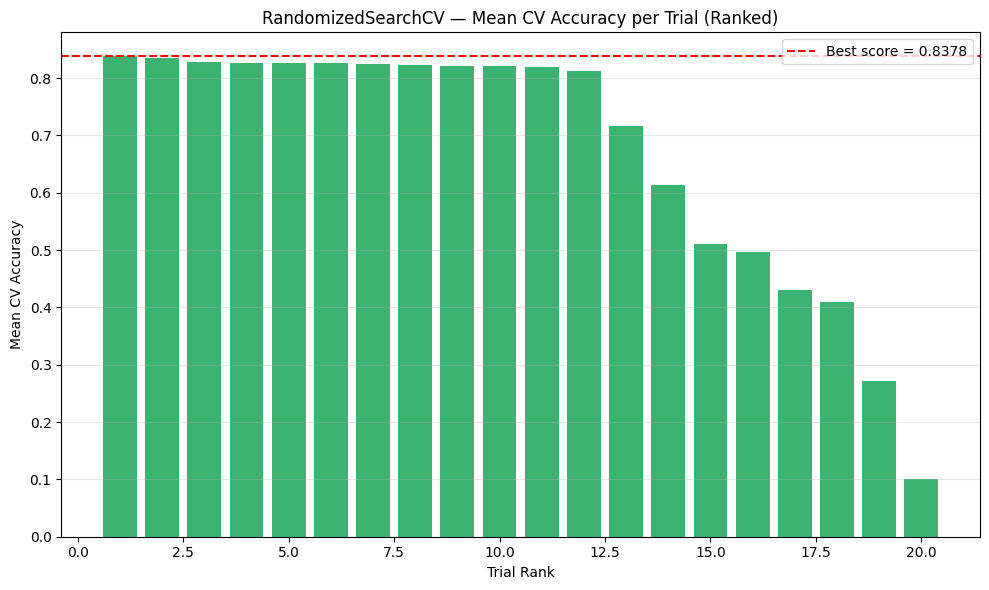

In [17]:
# Plot Hyperparameter Search Results (mean CV accuracy per trial, ranked)
plt.figure(figsize=(10, 6))
sorted_scores = cv_results_df.sort_values('rank_test_score')['mean_test_score'].values
trial_ranks = np.arange(1, len(sorted_scores) + 1)

plt.bar(trial_ranks, sorted_scores, color='mediumseagreen')
plt.axhline(random_search.best_score_, color='red', linestyle='--',
            label=f'Best score = {random_search.best_score_:.4f}')
plt.title('RandomizedSearchCV — Mean CV Accuracy per Trial (Ranked)')
plt.xlabel('Trial Rank')
plt.ylabel('Mean CV Accuracy')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('hyperparameter_search_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
best_hidden_layers = best_params['hidden_layers']
best_hidden_neurons = best_params['hidden_neurons']
best_learning_rate = best_params['learning_rate']
best_batch_size = best_params['batch_size']
best_epochs = best_params['epochs']
best_optimizer = best_params['optimizer']
best_activation = best_params['activation']
best_dropout_rate = best_params['dropout_rate']

optimized_model = build_mlp(
    hidden_layers=best_hidden_layers,
    hidden_neurons=best_hidden_neurons,
    learning_rate=best_learning_rate,
    optimizer=best_optimizer,
    activation=best_activation,
    dropout_rate=best_dropout_rate,
    meta={'n_features_in_': 784, 'n_classes_': 10}
)

optimized_model.summary()

Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_290 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_176 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
start_time = time.time()
optimized_history = optimized_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=best_epochs,
    batch_size=best_batch_size,
    verbose=1
)
print(f"\nOptimized model training completed in {time.time() - start_time:.1f} seconds")

Epoch 1/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.2724 - loss: 2.1173 - val_accuracy: 0.5903 - val_loss: 1.8610
Epoch 2/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4867 - loss: 1.7531 - val_accuracy: 0.6480 - val_loss: 1.5735
Epoch 3/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5517 - loss: 1.5215 - val_accuracy: 0.6813 - val_loss: 1.3688
Epoch 4/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5939 - loss: 1.3587 - val_accuracy: 0.7013 - val_loss: 1.2220
Epoch 5/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6227 - loss: 1.2392 - val_accuracy: 0.7117 - val_loss: 1.1141
Epoch 6/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6418 - loss: 1.1489 - val_accuracy: 0.7223 - val_loss: 1.0328
Epoch 7/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6534 - loss: 1.0810 - val_accuracy: 0.7278 - val_loss: 0.9696
Epoch 8/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6656 - loss: 1.

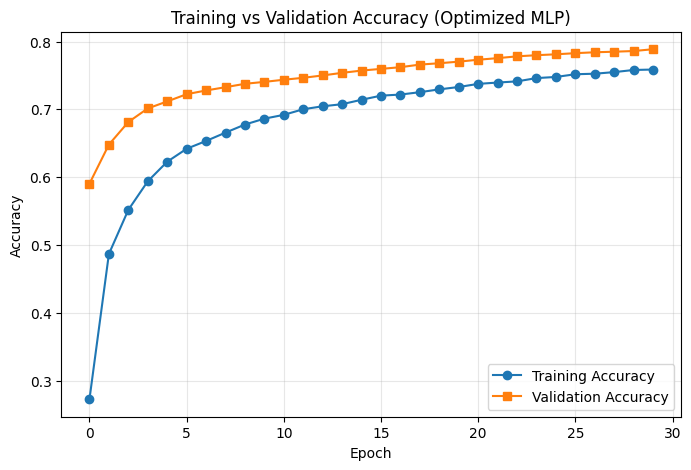

In [21]:
# Optimized model: Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(optimized_history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy (Optimized MLP)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('optimized_accuracy_vs_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

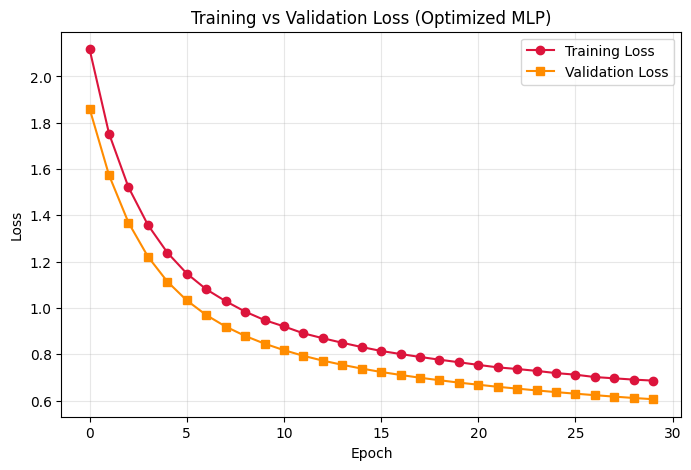

In [22]:
# Optimized model: Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history['loss'], label='Training Loss', marker='o', color='crimson')
plt.plot(optimized_history.history['val_loss'], label='Validation Loss', marker='s', color='darkorange')
plt.title('Training vs Validation Loss (Optimized MLP)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('optimized_loss_vs_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Evaluate optimized model on the test set
y_pred_probs_opt = optimized_model.predict(x_test)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

acc_opt = accuracy_score(y_true, y_pred_opt)
prec_opt = precision_score(y_true, y_pred_opt, average='weighted')
rec_opt = recall_score(y_true, y_pred_opt, average='weighted')
f1_opt = f1_score(y_true, y_pred_opt, average='weighted')

print("Optimized Model — Test Set Metrics")
print("-" * 40)
print(f"Accuracy : {acc_opt:.4f}")
print(f"Precision: {prec_opt:.4f}")
print(f"Recall   : {rec_opt:.4f}")
print(f"F1-score : {f1_opt:.4f}")

optimized_metrics = {'accuracy': acc_opt, 'precision': prec_opt, 'recall': rec_opt, 'f1': f1_opt}

print("\nClassification Report")
print("-" * 40)
print(classification_report(y_true, y_pred_opt, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Optimized Model — Test Set Metrics
----------------------------------------
Accuracy : 0.7785
Precision: 0.7744
Recall   : 0.7785
F1-score : 0.7737

Classification Report
----------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.80      0.76      1000
     Trouser       0.97      0.93      0.95      1000
    Pullover       0.67      0.60      0.63      1000
       Dress       0.76      0.84      0.80      1000
        Coat       0.61      0.71      0.66      1000
      Sandal       0.93      0.81      0.86      1000
       Shirt       0.48      0.35      0.40      1000
     Sneaker       0.84      0.86      0.85      1000
         Bag       0.91      0.93      0.92      1000
  Ankle boot       0.85      0.94      0.90      1000

    accuracy                           0.78     10000
   macro avg       0.77      0.78      0.77     10000
weighted avg       0.77      0.78      0.77

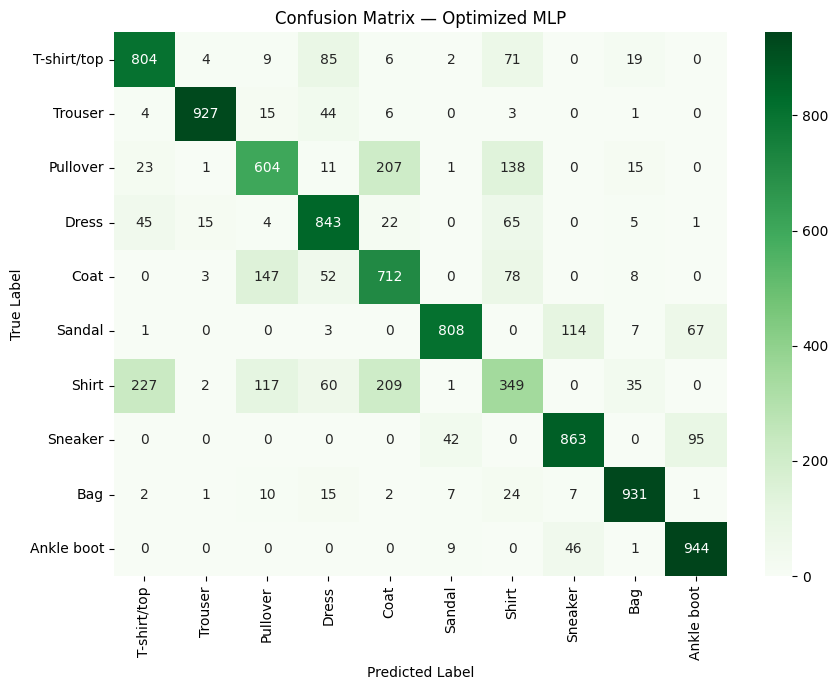

In [24]:
# Confusion Matrix — Optimized Model
cm_opt = confusion_matrix(y_true, y_pred_opt)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Optimized MLP')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
comparison_df = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Optimized': optimized_metrics
}).T

print(comparison_df)
print("\nBest Hyperparameters used for the optimized model:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

           accuracy  precision  recall        f1
Baseline     0.8809   0.883595  0.8809  0.878680
Optimized    0.7785   0.774436  0.7785  0.773745

Best Hyperparameters used for the optimized model:
  optimizer: sgd
  learning_rate: 0.001
  hidden_neurons: 32
  hidden_layers: 1
  epochs: 30
  dropout_rate: 0.2
  batch_size: 16
  activation: sigmoid


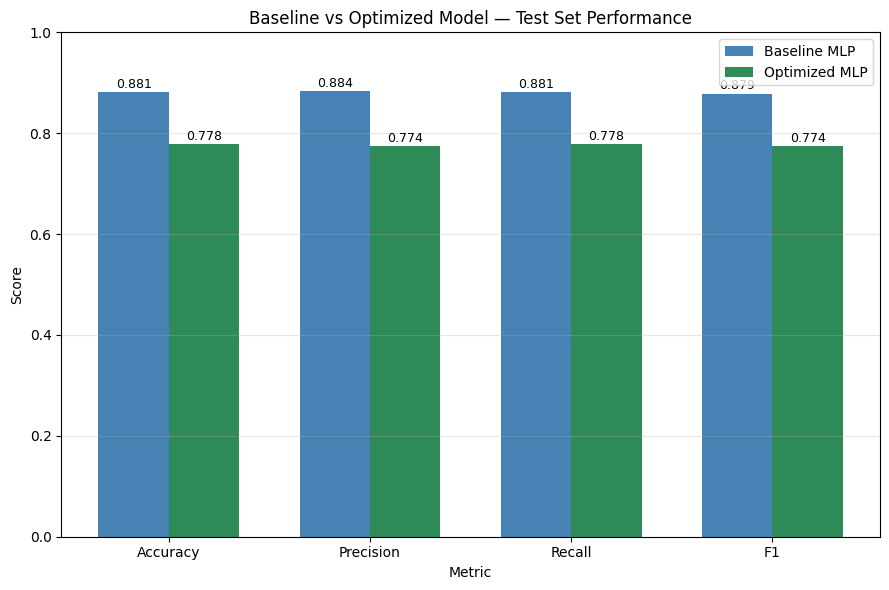

In [26]:
# Best Model Accuracy Comparison plot
metrics_labels = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
baseline_vals = [baseline_metrics[m] for m in metrics_labels]
optimized_vals = [optimized_metrics[m] for m in metrics_labels]

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline MLP', color='steelblue')
bars2 = ax.bar(x + width/2, optimized_vals, width, label='Optimized MLP', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Baseline vs Optimized Model — Test Set Performance')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_labels])
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('best_model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
improvement = acc_opt - acc
print(f"Accuracy improvement from hyperparameter optimization: {improvement*100:.2f} percentage points")
print(f"Baseline Accuracy : {acc:.4f}")
print(f"Optimized Accuracy: {acc_opt:.4f}")

Accuracy improvement from hyperparameter optimization: -10.24 percentage points
Baseline Accuracy : 0.8809
Optimized Accuracy: 0.7785
